# Supplementary Notebook 21: MNAR Null Calibration

- **License:** [Creative Commons Attribution-NonCommercial 4.0 International License](https://creativecommons.org/licenses/by-nc/4.0/)
- **Version:** 0.8
- **Date:** 2026-03-18

## Overview

This notebook evaluates whether MNAR-pattern missingness inflates Type I error in ProteoForge, COPF, and PeCorA when the underlying data-generating process is truly null. It addresses Reviewer 3 (R3-Major-3): *"Evaluate the type I error rate when MNAR-pattern missingness is introduced to truly null peptides ... demonstrate that imputation-induced signal inflation is not a confound."*

**Design:** The publication run pools **50 independent MNAR-null repeats** generated with the same `sims` framework used in the main study, with no true peptide-by-condition interaction. MNAR missingness is then introduced using `sims.amputation()` under the Sim2 pattern: 100 proteins with sparse random missingness, 100 proteins with complete-condition missing blocks, and 300 proteins remaining fully observed. Missing values are completed with downshifted draws so that all methods are evaluated on the same MNAR-null inputs. ProteoForge is assessed with its robust linear model (RLM) workflow, while COPF and PeCorA are run through their standard pipelines.

This K=50 notebook is written so that every panel remains tied to the artifacts actually loaded at runtime. The run-coverage table below is therefore the authoritative record of how many repeats contributed to each method-specific summary, figure, and table.

Unless stated otherwise, plotted curves summarize repeat-level behavior by showing the median across repeats with a run-wise 95% interval. Supplementary diagnostics isolate the complete-condition-missing subset from the broader null calibration target. A final supplemental section also adds two non-null Sim2 operating-point examples so the reader can see how empirical FDR and power behave once true proteoforms are present under MNAR.

| Part | Level | Question |
|------|-------|----------|
| 1 | Raw p-values | Do MNAR-null p-values remain approximately Uniform(0,1)? |
| 2 | Peptide (identification) | Does empirical FPR track the nominal threshold α? |
| 3 | Protein | How often is a null protein called significant under MNAR? |
| 4 | Grouping (proteoform) | How often are proteoform groups predicted when none exist? |
| 5 | Baseline comparison | How different is the MNAR null from the matched no-missingness baseline? |
| 6 | Non-null Sim2 snapshots | For two representative Sim2 datasets, what FDR-power trade-off remains after MNAR imputation? |

## Companion Scripts

- `Revisions/logic/python/simulation/fdr_calibration/generate_mnar_null_data.py` — builds the MNAR null datasets.
- `Revisions/logic/r/simulation/fdr_calibration/run_r_methods_mnar.R` — runs COPF and PeCorA on the same MNAR-null inputs.

In [45]:
import os, sys, time, warnings
import multiprocessing as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats
import pyarrow.feather as pf_io

# Resolve project root (3 levels up from this notebook)
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..', '..'))
if not os.path.isfile(os.path.join(PROJECT_ROOT, 'requirements.txt')):
    _d = NOTEBOOK_DIR
    for _ in range(6):
        if os.path.isfile(os.path.join(_d, 'requirements.txt')):
            PROJECT_ROOT = _d
            break
        _d = os.path.dirname(_d)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

def project_relative_label(path, root=PROJECT_ROOT):
    rel = os.path.relpath(path, root)
    name = os.path.basename(root.rstrip(os.sep))
    return name if rel == '.' else os.path.join(name, rel)

from src import utils
from Simulation import sims
from ProteoForge import model, disluster, correct

print(f"Project root: {project_relative_label(PROJECT_ROOT)}")
print("Libraries loaded successfully.")

Project root: Analysis_with_ProteoForge
Libraries loaded successfully.


In [46]:
# ── Visual identity ────────────────────────────────────────────────
METHOD_COLORS = {
    'ProteoForge': '#e54f2a',
    'PeCorA':      '#fca311',
    'COPF':        '#139593',
}
RAW_COLOR  = '#222222'
DIAG_COLOR = '#999999'

sns.set_theme(style='white', context='paper', font_scale=1,
              rc={'figure.figsize': (6, 4), 'font.family': 'sans-serif',
                  'font.sans-serif': ['Arial']})
figure_dpi = 300

# ── Paths ─────────────────────────────────────────────────────────
notebook_name = 'MNARCalibration'
output_path = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'simulation', 'mnar_fdr_calibration')
figure_path = os.path.join(output_path, 'figures')
os.makedirs(output_path, exist_ok=True)
os.makedirs(os.path.join(figure_path, 'pdf'), exist_ok=True)

# Reference: no-MNAR null calibration output (for comparison)
nomnar_output_path = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'simulation', 'fdr_calibration')

# ── Helpers ───────────────────────────────────────────────────────
def save_fig(fig, name):
    for ext, subdir in [('png', '.'), ('pdf', 'pdf')]:
        out = os.path.join(figure_path, subdir, f'{name}.{ext}')
        os.makedirs(os.path.dirname(out), exist_ok=True)
        fig.savefig(out, dpi=figure_dpi, bbox_inches='tight')
    print(f"  Saved: {name}.png / .pdf")

print(f"Output folder: {project_relative_label(output_path)}")
print(f"Figure folder: {project_relative_label(figure_path)}")

Output folder: Analysis_with_ProteoForge/Revisions/outputs/simulation/mnar_fdr_calibration
Figure folder: Analysis_with_ProteoForge/Revisions/outputs/simulation/mnar_fdr_calibration/figures


---

## Simulation Parameters

Null data are generated with the same `sims` framework used elsewhere in the project. MNAR missingness follows the Sim2 pattern exactly: `sims.amputation()` with `n_amputate_1=100` for sparse random missingness at 35% rate and `n_amputate_2=100` for complete-condition missing blocks. The remaining 300 proteins remain fully observed.

For publication, this notebook pools **50 independent repeats**. Missing values are completed with downshifted draws before the comparison methods are run, while ProteoForge continues to normalize from the original MNAR table and fit the robust linear model on the retained observations. This split preserves a fair cross-method comparison while avoiding normalization artifacts inside ProteoForge.

In [31]:
startTime = time.time()

# ── Null simulation parameters (publication setting) ──────────────
K            = 50
base_seed    = 42
n_proteins   = 500
n_peptides   = (5, 50)
n_condition  = 3        # 1 control + 2 treatment
n_replicates = 10
model_to_use = 'rlm'    # Robust linear model
n_jobs       = min(mp.cpu_count() // 2, 16)

# ── MNAR parameters (match Sim2 exactly) ─────────────────────────
n_amp_sparse   = 100    # proteins with sparse random missingness
n_amp_compmiss = 100    # proteins with complete-condition blocks
sparse_miss_rate = 0.35 # per-value missing probability for sparse proteins

# ── Correction strategy ───────────────────────────────────────────
DEFAULT_CORRECTION = 'Two-step (Bonf-BH)'
correction_configs = {
    'Two-step (Bonf-BH)':  {'strategy': 'two-step',    'methods': ('bonferroni', 'fdr_bh')},
}

# ── Alpha grid ────────────────────────────────────────────────────
_log = list(utils.generate_thresholds(10.0, -15, 1, 0, 1, 0.1))
_mid = [round(v, 4) for v in np.arange(0.010, 0.105, 0.005).tolist()]
alpha_grid = sorted(set(_log + _mid))
alpha_grid = [a for a in alpha_grid if 0 < a <= 1.0]
alpha_arr  = np.array(alpha_grid)

print(f"K = {K} MNAR null runs | {n_proteins} proteins | {len(alpha_grid)} alpha points")
print(f"MNAR: n_amp_sparse={n_amp_sparse}, n_amp_compmiss={n_amp_compmiss}, sparse_miss_rate={sparse_miss_rate}")
print(f"Model: {model_to_use} (robust linear model)")
print(f"Default correction: {DEFAULT_CORRECTION}")
print(f"CPU cores: {n_jobs} / {mp.cpu_count()}")
print("Publication setting: figures and tables pool repeat-level results and report run-wise medians throughout.")

K = 50 MNAR null runs | 500 proteins | 41 alpha points
MNAR: n_amp_sparse=100, n_amp_compmiss=100, sparse_miss_rate=0.35
Model: rlm (robust linear model)
Default correction: Two-step (Bonf-BH)
CPU cores: 16 / 32
Publication setting: figures and tables pool repeat-level results and report run-wise medians throughout.


---

## Pipeline Execution

`simulate_mnar_null_rawpvals` loads the pre-generated MNAR null datasets and runs the ProteoForge identification and clustering workflow on the MNAR-null inputs. Sparse missing positions are excluded from model fitting, peptide-level testing is performed with the robust linear model (`RLM`) implemented in `ProteoForge.model.LinearModel`, and the resulting peptide p-values are carried forward to multiple-testing correction and clustering summaries.

The execution block below either loads cached artifacts or recomputes them. Its stdout is part of the supplementary record: it reports the actual repeat coverage loaded for ProteoForge, PeCorA, and COPF, plus the pooled number of peptide-level tests contributing to each downstream figure.

### Run Coverage And Pooling

All downstream panels use the loaded repeats reported below rather than assuming that every cache is present. Where multiple repeats are available, the notebook summarizes the median trajectory across runs and uses run-wise quantiles to show between-repeat variation.

For the publication run, the target is 50 repeats per method. If any cache is incomplete, the notebook will still render using the available runs, but the coverage table and figure subtitles should be treated as the definitive description of what was pooled.

In [32]:
def simulate_mnar_null_rawpvals(
        run_idx, base_seed, n_proteins, n_peptides, n_condition, n_replicates,
        model_to_use, n_jobs, verbose=True):
    """
    Load the canonical MNAR null dataset for run_idx and run ProteoForge.

    Handling of MNAR inputs:
      - Sparse-missing positions (isReal=0, isCompMiss=0) are excluded from the
        ProteoForge model fit.
      - The model is fit with ProteoForge's robust linear model (RLM).
      - Complete-condition missing peptides are retained and tracked separately
        for downstream summaries.
    """
    t0 = time.time()
    seed = base_seed + run_idx
    np.random.seed(seed)

    input_path = os.path.join(
        output_path, 'null_input', f'mnar_null_run_{run_idx}_InputData.feather')
    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"MNAR null input data not found: {project_relative_label(input_path)}\n"
            "Run generate_mnar_null_data.py first.")
    test_data = pd.read_feather(input_path)

    is_sparse = (test_data['isReal'] == 0) & (test_data['isCompMiss'] == 0)
    n_sparse = int(is_sparse.sum())
    model_data = test_data.loc[~is_sparse].copy()

    # LinearModel currently validates constructor inputs against the package
    # default model type, so provide a constant placeholder weight column even
    # though the actual fit below is RLM and does not use external weights.
    model_data['Weight'] = 1.0

    if verbose:
        print(f"    Run {run_idx + 1}: excluded {n_sparse:,} sparse-missing rows | "
              f"remaining {len(model_data):,}")

    cur_model = model.LinearModel(
        data=model_data,
        protein_col='Protein',
        peptide_col='Peptide',
        cond_col='Condition',
        intensity_col='adjIntensity',
        weight_col='Weight')
    result_data = cur_model.run_analysis(
        model_type=model_to_use,
        correction_strategy='two-step',
        correction_methods=('bonferroni', 'fdr_bh'),
        n_jobs=n_jobs)

    comp_miss_flag = (
        test_data[['Protein', 'Peptide', 'isCompMiss']]
        .groupby(['Protein', 'Peptide'])['isCompMiss'].max().reset_index())
    result_data = result_data.merge(
        comp_miss_flag,
        on=['Protein', 'Peptide'],
        how='left',
        suffixes=('_m', '')
    )
    if 'isCompMiss_m' in result_data.columns:
        result_data['isCompMiss'] = result_data['isCompMiss'].fillna(result_data['isCompMiss_m'])
        result_data.drop(columns=['isCompMiss_m'], inplace=True)
    result_data['has_comp_miss'] = (
        result_data.groupby(['Protein', 'PeptideID'])['isCompMiss'].transform('max'))

    result = (
        result_data[['Protein', 'PeptideID', 'pval', 'has_comp_miss']]
        .drop_duplicates(subset=['Protein', 'PeptideID'])
        .dropna(subset=['pval']).copy())
    result.insert(0, 'run', run_idx + 1)
    result['pertPFG'] = -1

    clust_result = disluster.distance_and_cluster(
        data=result_data,
        protein_col='Protein',
        peptide_col='PeptideID',
        cond_col='Condition',
        quant_col='adjIntensity',
        clustering_params={
            'min_clusters': 1,
            'distance_transform': 'corr',
            'clustering_method': 'hybrid_outlier_cut',
            'linkage_method': 'ward',
            'distance_metric': 'euclidean'
        },
        n_jobs=n_jobs,
        verbose=False
    )
    clust_map = (
        clust_result[['Protein', 'PeptideID', 'cluster_label']]
        .drop_duplicates(subset=['Protein', 'PeptideID'])
        .rename(columns={'cluster_label': 'ClusterID'}))
    result = result.merge(clust_map, on=['Protein', 'PeptideID'], how='left')

    elapsed = time.time() - t0
    if verbose:
        n_comp = int(result['has_comp_miss'].sum())
        n_clust = result['ClusterID'].nunique()
        print(f"    Run {run_idx + 1:>2}/{K}: {len(result):,} tests "
              f"| {n_comp} complete-miss peps | {n_clust} clusters | {elapsed:.1f}s")
    return result


def apply_correction(pval_df, strategy, methods):
    if strategy == 'two-step':
        prot_m, glob_m = methods
        prt = pval_df.groupby('Protein')['pval'].transform(
            lambda x: correct.for_multiple_tests(x, correction_type=prot_m))
        return np.asarray(correct.for_multiple_tests(prt, correction_type=glob_m))
    elif strategy == 'global':
        return np.asarray(
            correct.for_multiple_tests(pval_df['pval'], correction_type=methods))
    elif strategy == 'protein-only':
        return np.asarray(
            pval_df.groupby('Protein')['pval'].transform(
                lambda x: correct.for_multiple_tests(x, correction_type=methods)))
    else:
        raise ValueError(f"Unknown correction strategy: {strategy!r}")


print("Functions defined: simulate_mnar_null_rawpvals, apply_correction")

Functions defined: simulate_mnar_null_rawpvals, apply_correction


In [33]:
# ── Run ProteoForge (or load cache) ───────────────────────────────
cond_name = DEFAULT_CORRECTION
cache_path = os.path.join(output_path, f'rawpvals_full_MNAR_{cond_name.replace(" ", "_")}_K{K}.feather')

if os.path.exists(cache_path):
    print(f"Loading cached ProteoForge results: {os.path.basename(cache_path)}")
    raw_pval_store = {cond_name: pd.read_feather(cache_path)}
else:
    print(f"Running ProteoForge on K={K} MNAR null datasets...")
    per_run = []
    for k in range(K):
        res = simulate_mnar_null_rawpvals(
            k, base_seed, n_proteins, n_peptides, n_condition, n_replicates,
            model_to_use, n_jobs)
        per_run.append(res)
    all_raw = pd.concat(per_run, ignore_index=True)

    # Apply correction
    cfg = correction_configs[cond_name]
    all_raw['adj_pval'] = apply_correction(all_raw, cfg['strategy'], cfg['methods'])
    all_raw['correction'] = cond_name

    all_raw.to_feather(cache_path)
    raw_pval_store = {cond_name: all_raw}
    print(f"  Saved: {os.path.basename(cache_path)}")

all_df = raw_pval_store[cond_name]
pf_run_ids = sorted(all_df['run'].unique())
pf_run_count = len(pf_run_ids)
print(f"\nLoaded {len(all_df):,} raw p-values across {pf_run_count} ProteoForge runs")
print(f"  Complete-miss peptides: {int(all_df['has_comp_miss'].sum()):,}")

# ── Load R method results ─────────────────────────────────────────
r_id_path  = os.path.join(output_path, f'rmethod_id_fpr_K{K}.csv')
r_grp_path = os.path.join(output_path, f'rmethod_grp_fpr_K{K}.csv')

copf_runs, pec_runs = [], []
copf_run_ids, pec_run_ids = [], []
has_r_results = os.path.exists(r_id_path)

if has_r_results:
    print(f"Loaded R method results: {os.path.basename(r_id_path)}")
else:
    print("R method results not found — loading COPF/PeCorA feathers directly.")

for k in range(K):
    run_id = k + 1
    copf_f = os.path.join(output_path, f'copf_mnar_null_run{k:02d}.feather')
    pec_f  = os.path.join(output_path, f'pecora_mnar_null_run{k:02d}.feather')
    if os.path.exists(copf_f):
        copf_runs.append(pd.read_feather(copf_f))
        copf_run_ids.append(run_id)
    if os.path.exists(pec_f):
        pec_runs.append(pd.read_feather(pec_f))
        pec_run_ids.append(run_id)

copf_run_count = len(copf_runs)
pec_run_count = len(pec_runs)
print(f"COPF runs loaded: {copf_run_count}, PeCorA runs loaded: {pec_run_count}")

# ── Annotate comp-miss status for R methods ───────────────────────
# Track which peptides had complete-condition amputation (imputation-induced signal)
comp_miss_peptides = {}
comp_miss_proteins = {}
for run_id in pf_run_ids:
    input_path = os.path.join(
        output_path, 'null_input', f'mnar_null_run_{run_id - 1}_InputData.feather')
    inp = pd.read_feather(input_path, columns=['Protein', 'Peptide', 'isCompMiss'])
    cm = inp.groupby(['Protein', 'Peptide'])['isCompMiss'].max().reset_index()
    cm_mask = cm['isCompMiss'] == 1
    comp_miss_peptides[run_id] = set(zip(cm.loc[cm_mask, 'Protein'], cm.loc[cm_mask, 'Peptide']))
    comp_miss_proteins[run_id] = set(cm.loc[cm_mask, 'Protein'])

for i, df_p in enumerate(pec_runs):
    run_id = pec_run_ids[i]
    cm_set = comp_miss_peptides[run_id]
    pec_runs[i] = df_p.copy()
    pec_runs[i]['has_comp_miss'] = [
        int((p, q) in cm_set) for p, q in zip(df_p['Protein'], df_p['Peptide'])]

for i, df_c in enumerate(copf_runs):
    run_id = copf_run_ids[i]
    copf_runs[i] = df_c.copy()
    copf_runs[i]['has_comp_miss'] = (
        copf_runs[i]['protein_id'].isin(comp_miss_proteins[run_id]).astype(int))

pec_by_run = dict(zip(pec_run_ids, pec_runs))
copf_by_run = dict(zip(copf_run_ids, copf_runs))

# ── Collect raw p-values (ALL peptides — including comp-miss) ─────
pf_raw   = all_df['pval'].dropna().values
pec_raw  = np.concatenate([d['pvalue'].dropna().values for d in pec_runs]) if pec_runs else np.array([])
copf_raw = np.concatenate([d['proteoform_score_pval'].dropna().values for d in copf_runs]) if copf_runs else np.array([])

# ── Calibration curves per run (ALL peptides) ─────────────────────
cal_curves = {}
for rid, run_df in all_df.groupby('run'):
    adj_pvals = run_df['adj_pval'].dropna().values
    n = len(adj_pvals)
    cal_curves[(cond_name, rid)] = np.array([(adj_pvals <= a).sum() / n for a in alpha_arr])

n_cm = int(all_df.drop_duplicates(['run', 'Protein', 'PeptideID']).groupby('run')['has_comp_miss'].sum().mean())
n_all = int(all_df.drop_duplicates(['run', 'Protein', 'PeptideID']).groupby('run').size().mean())
run_coverage = pd.DataFrame([
    {'Method': 'ProteoForge', 'Repeats loaded': pf_run_count, 'Total pooled p-values': len(pf_raw)},
    {'Method': 'PeCorA', 'Repeats loaded': pec_run_count, 'Total pooled p-values': len(pec_raw)},
    {'Method': 'COPF', 'Repeats loaded': copf_run_count, 'Total pooled p-values': len(copf_raw)},
])
display(run_coverage)

if pf_run_count > 0 and pf_run_count == pec_run_count == copf_run_count and pec_run_count > 0:
    matched_repeat_label = f'{pf_run_count} matched repeats pooled'
else:
    matched_repeat_label = f'PF={pf_run_count}, PeCorA={pec_run_count}, COPF={copf_run_count} repeats'

if pf_run_count > 0 and pf_run_count == copf_run_count and copf_run_count > 0:
    grouping_repeat_label = f'{pf_run_count} matched PF/COPF repeats pooled'
else:
    grouping_repeat_label = f'PF={pf_run_count}, COPF={copf_run_count} repeats'

pf_repeat_label = f'{pf_run_count} repeats pooled'

print(f"\n── Complete-miss accounting ────────────────────────────────")
print(f"Comp-miss peptides per run:     ~{n_cm}")
print(f"Total peptides per run:         ~{n_all}")
print(f"PF total p-vals:   {len(pf_raw):,}")
print(f"PeCorA total:      {len(pec_raw):,}")
print(f"COPF total:        {len(copf_raw):,}")
print(f"Repeat coverage:   {matched_repeat_label}")

Running ProteoForge on K=50 MNAR null datasets...
    Run 1: excluded 11,688 sparse-missing rows | remaining 157,812
    Run  1/50: 5,650 tests | 100 complete-miss peps | 9 clusters | 7.5s
    Run 2: excluded 12,426 sparse-missing rows | remaining 164,904
    Run  2/50: 5,911 tests | 100 complete-miss peps | 9 clusters | 7.8s
    Run 3: excluded 11,778 sparse-missing rows | remaining 151,692
    Run  3/50: 5,449 tests | 100 complete-miss peps | 9 clusters | 7.2s
    Run 4: excluded 12,384 sparse-missing rows | remaining 165,036
    Run  4/50: 5,914 tests | 100 complete-miss peps | 10 clusters | 7.7s
    Run 5: excluded 11,697 sparse-missing rows | remaining 157,293
    Run  5/50: 5,633 tests | 101 complete-miss peps | 10 clusters | 7.4s
    Run 6: excluded 13,006 sparse-missing rows | remaining 167,024
    Run  6/50: 6,001 tests | 100 complete-miss peps | 9 clusters | 8.0s
    Run 7: excluded 12,657 sparse-missing rows | remaining 149,673
    Run  7/50: 5,411 tests | 100 complete-miss 

,Method,Repeats loaded,Total pooled p-values
0,ProteoForge,50,283770
1,PeCorA,50,283720
2,COPF,50,274632



── Complete-miss accounting ────────────────────────────────
Comp-miss peptides per run:     ~100
Total peptides per run:         ~5675
PF total p-vals:   283,770
PeCorA total:      283,720
COPF total:        274,632
Repeat coverage:   50 matched repeats pooled


In [34]:
# ── Diagnostic: non-complete-miss FPR and complete-miss subset rates ──
print("=" * 70)
print("Structured complete-miss peptides are summarized separately from the")
print("broader null set because they arise from a dedicated MNAR pattern.")
print("The non-complete-miss subset remains the main null-calibration reference.")
print("=" * 70)

pf_ncm = all_df[all_df['has_comp_miss'] == 0]['pval'].dropna()
pf_cm  = all_df[all_df['has_comp_miss'] == 1]['pval'].dropna()
print(f"\n── ProteoForge (all {len(all_df):,} peptides tested; {pf_repeat_label}) ──")
print(f"  Non-complete-miss: {len(pf_ncm):,} peps, sig(p<0.05)={100*(pf_ncm<0.05).mean():.1f}%")
print(f"  Complete-miss:     {len(pf_cm):,} peps, sig(p<0.05)={100*(pf_cm<0.05).mean():.1f}%")

print(f"\n── PeCorA ({sum(len(d) for d in pec_runs):,} peptides tested across {pec_run_count} runs) ──")
for i, df_p in enumerate(pec_runs):
    run_id = pec_run_ids[i]
    n_total_input = pd.read_feather(
        os.path.join(output_path, 'null_input', f'mnar_null_run_{run_id - 1}_InputData.feather'),
        columns=['Protein', 'Peptide']).drop_duplicates().shape[0]
    pec_ncm = df_p.loc[df_p['has_comp_miss'] == 0, 'pvalue'].dropna()
    pec_cm = df_p.loc[df_p['has_comp_miss'] == 1, 'pvalue'].dropna()
    n_dropped = n_total_input - len(df_p)
    print(f"  Run {run_id}: total={n_total_input}, tested={len(df_p)} ({n_dropped} dropped) | "
          f"NCM sig(p<0.05)={100*(pec_ncm<0.05).mean():.1f}% ({len(pec_ncm)} peps) | "
          f"CM sig={100*(pec_cm<0.05).mean():.1f}% ({len(pec_cm)} peps)")

print(f"\n── COPF ({sum(len(d) for d in copf_runs):,} peptides across {copf_run_count} runs, using raw p-values) ──")
for i, df_c in enumerate(copf_runs):
    run_id = copf_run_ids[i]
    copf_ncm = df_c.loc[df_c['has_comp_miss'] == 0, 'proteoform_score_pval'].dropna()
    copf_cm = df_c.loc[df_c['has_comp_miss'] == 1, 'proteoform_score_pval'].dropna()
    adj_min = df_c['proteoform_score_pval_adj'].min()
    print(f"  Run {run_id}: NCM sig(raw p<0.05)={100*(copf_ncm<0.05).mean():.1f}% ({len(copf_ncm)} peps) | "
          f"CM sig(raw)={100*(copf_cm<0.05).mean():.1f}% ({len(copf_cm)} peps) | "
          f"adj min={adj_min:.4f}")

print(f"\n── Summary at raw p < 0.05 ──")
pf_ncm_all = np.concatenate([
    all_df.loc[(all_df['run'] == r) & (all_df['has_comp_miss'] == 0), 'pval'].dropna().values
    for r in pf_run_ids])
pf_cm_all = np.concatenate([
    all_df.loc[(all_df['run'] == r) & (all_df['has_comp_miss'] == 1), 'pval'].dropna().values
    for r in pf_run_ids])
pec_ncm_all = np.concatenate([d.loc[d['has_comp_miss'] == 0, 'pvalue'].dropna().values for d in pec_runs]) if pec_runs else np.array([])
pec_cm_all = np.concatenate([d.loc[d['has_comp_miss'] == 1, 'pvalue'].dropna().values for d in pec_runs]) if pec_runs else np.array([])
copf_ncm_all = np.concatenate([d.loc[d['has_comp_miss'] == 0, 'proteoform_score_pval'].dropna().values for d in copf_runs]) if copf_runs else np.array([])
copf_cm_all = np.concatenate([d.loc[d['has_comp_miss'] == 1, 'proteoform_score_pval'].dropna().values for d in copf_runs]) if copf_runs else np.array([])

print(f"  {'Method':12s} | {'Non-CM FPR':>12s} | {'CM subset':>12s} | {'N tested':>10s}")
print(f"  {'-'*12} | {'-'*12} | {'-'*12} | {'-'*10}")
print(f"  {'ProteoForge':12s} | {100*(pf_ncm_all<0.05).mean():11.1f}% | {100*(pf_cm_all<0.05).mean():11.1f}% | {len(pf_ncm_all)+len(pf_cm_all):>10,}")
if len(pec_ncm_all):
    print(f"  {'PeCorA':12s} | {100*(pec_ncm_all<0.05).mean():11.1f}% | {100*(pec_cm_all<0.05).mean():11.1f}% | {len(pec_ncm_all)+len(pec_cm_all):>10,}")
if len(copf_ncm_all):
    print(f"  {'COPF (raw)':12s} | {100*(copf_ncm_all<0.05).mean():11.1f}% | {100*(copf_cm_all<0.05).mean():11.1f}% | {len(copf_ncm_all)+len(copf_cm_all):>10,}")
print("\n  The non-complete-miss subset is the main null-calibration reference.")

Structured complete-miss peptides are summarized separately from the
broader null set because they arise from a dedicated MNAR pattern.
The non-complete-miss subset remains the main null-calibration reference.

── ProteoForge (all 283,770 peptides tested; 50 repeats pooled) ──
  Non-complete-miss: 278,765 peps, sig(p<0.05)=4.8%
  Complete-miss:     5,005 peps, sig(p<0.05)=6.8%

── PeCorA (283,720 peptides tested across 50 runs) ──
  Run 1: total=5650, tested=5649 (1 dropped) | NCM sig(p<0.05)=4.8% (5549 peps) | CM sig=100.0% (100 peps)
  Run 2: total=5911, tested=5910 (1 dropped) | NCM sig(p<0.05)=5.3% (5810 peps) | CM sig=100.0% (100 peps)
  Run 3: total=5449, tested=5448 (1 dropped) | NCM sig(p<0.05)=5.7% (5348 peps) | CM sig=100.0% (100 peps)
  Run 4: total=5914, tested=5913 (1 dropped) | NCM sig(p<0.05)=4.5% (5813 peps) | CM sig=100.0% (100 peps)
  Run 5: total=5633, tested=5632 (1 dropped) | NCM sig(p<0.05)=5.2% (5531 peps) | CM sig=99.0% (101 peps)
  Run 6: total=6001, tested=600

---

## Complete-Condition Missing Blocks

A subset of proteins in the MNAR design contains one peptide-condition block that is completely missing before completion. This subset is useful for summarizing how each method responds to structured MNAR input after the table has been completed.

Throughout the notebook, peptides with complete-condition missingness are reported separately from the broader null set. The clean-protein subset remains the primary calibration reference, whereas the complete-miss subset serves as a supplementary stress-test for method behavior under structured MNAR input.

- **ProteoForge (RLM)** applies robust regression to the retained observations and remains comparatively stable on this subset.
- **PeCorA** is more sensitive on this subset because its interaction model is fit to the completed table.
- **COPF** remains conservative when evaluated through its raw proteoform score p-values in this setting.

## Diagnostic: Peptides with Complete-Condition Missingness

The next figure compares the peptide-level p-value distribution for peptides with complete-condition missingness against the remaining peptides. This panel is included as a supplementary diagnostic and is not used as the primary null-calibration target.

The distributions are pooled across the loaded repeats, so the sample sizes shown in the legend reflect the combined diagnostic subset rather than a single run.

In [35]:
# ── Deep diagnostic: clean vs sparse-hit vs complete-miss subsets ──
print("=" * 70)
print("DEEP DIAGNOSTIC: Breaking down rates by protein category")
print("=" * 70)

for run_id in pf_run_ids:
    inp = pd.read_feather(
        os.path.join(output_path, 'null_input', f'mnar_null_run_{run_id - 1}_InputData.feather')
    )

    pro_real = inp.groupby('Protein')['isReal'].min()
    sparse_proteins = set(pro_real[pro_real == 0].index) - comp_miss_proteins[run_id]
    clean_proteins = set(pro_real[pro_real == 1].index)

    run_df = all_df[all_df['run'] == run_id]
    pf_clean = run_df[run_df['Protein'].isin(clean_proteins)]['pval'].dropna()
    pf_sparse = run_df[
        run_df['Protein'].isin(sparse_proteins) & (run_df['has_comp_miss'] == 0)
    ]['pval'].dropna()
    pf_cm = run_df[run_df['has_comp_miss'] == 1]['pval'].dropna()

    pec_df = pec_by_run.get(run_id)
    if pec_df is not None:
        pec_clean = pec_df[pec_df['Protein'].isin(clean_proteins)]['pvalue'].dropna()
        pec_sparse = pec_df[
            pec_df['Protein'].isin(sparse_proteins) & (pec_df['has_comp_miss'] == 0)
        ]['pvalue'].dropna()
        pec_cm = pec_df[pec_df['has_comp_miss'] == 1]['pvalue'].dropna()
    else:
        pec_clean = pec_sparse = pec_cm = np.array([])

    copf_df = copf_by_run.get(run_id)
    if copf_df is not None:
        copf_clean = copf_df[copf_df['protein_id'].isin(clean_proteins)]['proteoform_score_pval'].dropna()
        copf_sparse = copf_df[
            copf_df['protein_id'].isin(sparse_proteins) & (copf_df['has_comp_miss'] == 0)
        ]['proteoform_score_pval'].dropna()
        copf_cm = copf_df[copf_df['has_comp_miss'] == 1]['proteoform_score_pval'].dropna()
    else:
        copf_clean = copf_sparse = copf_cm = np.array([])

    print(f"\n  Run {run_id}: clean={len(clean_proteins)} proteins, sparse={len(sparse_proteins)}, comp-miss={len(comp_miss_proteins[run_id])}")
    print(f"    {'Category':20s} | {'PF':>8s} | {'PeCorA':>8s} | {'COPF':>8s} | {'N PF':>8s}")
    print(f"    {'-'*20} | {'-'*8} | {'-'*8} | {'-'*8} | {'-'*8}")
    print(f"    {'Clean proteins':20s} | {100*(pf_clean<0.05).mean():7.1f}% | {100*(pec_clean<0.05).mean() if len(pec_clean) else np.nan:7.1f}% | {100*(copf_clean<0.05).mean() if len(copf_clean) else np.nan:7.1f}% | {len(pf_clean):>8,}")
    print(f"    {'Sparse-hit proteins':20s} | {100*(pf_sparse<0.05).mean():7.1f}% | {100*(pec_sparse<0.05).mean() if len(pec_sparse) else np.nan:7.1f}% | {100*(copf_sparse<0.05).mean() if len(copf_sparse) else np.nan:7.1f}% | {len(pf_sparse):>8,}")
    print(f"    {'Comp-miss subset':20s} | {100*(pf_cm<0.05).mean():7.1f}% | {100*(pec_cm<0.05).mean() if len(pec_cm) else np.nan:7.1f}% | {100*(copf_cm<0.05).mean() if len(copf_cm) else np.nan:7.1f}% | {len(pf_cm):>8,}")

print("\n  Clean-protein rates remain the main null-calibration reference.")
print("  Sparse-hit and complete-miss subsets are shown to summarize each method's response to MNAR structure in the completed input table.")

DEEP DIAGNOSTIC: Breaking down rates by protein category

  Run 1: clean=300 proteins, sparse=100, comp-miss=100
    Category             |       PF |   PeCorA |     COPF |     N PF
    -------------------- | -------- | -------- | -------- | --------
    Clean proteins       |     4.7% |     4.6% |     0.0% |    3,361
    Sparse-hit proteins  |     4.4% |     7.4% |     0.0% |    1,103
    Comp-miss subset     |     5.0% |   100.0% |     0.0% |      100

  Run 2: clean=300 proteins, sparse=100, comp-miss=100
    Category             |       PF |   PeCorA |     COPF |     N PF
    -------------------- | -------- | -------- | -------- | --------
    Clean proteins       |     4.8% |     4.8% |     0.0% |    3,571
    Sparse-hit proteins  |     4.8% |     6.6% |     0.0% |    1,175
    Comp-miss subset     |     9.0% |   100.0% |     0.0% |      100

  Run 3: clean=300 proteins, sparse=100, comp-miss=100
    Category             |       PF |   PeCorA |     COPF |     N PF
    ------------

  Saved: comp_miss_diagnostic.png / .pdf


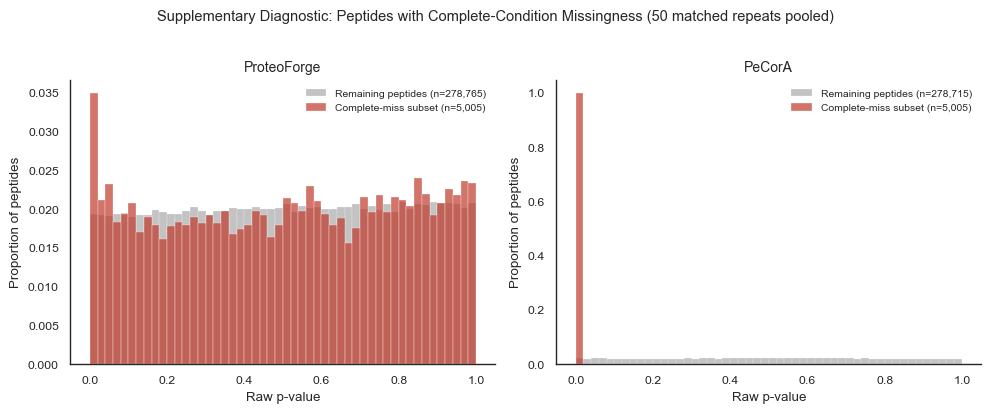

ProteoForge complete-miss subset: 5,005 | % sig (p<0.05) = 6.8% | mean p = 0.5058
ProteoForge remaining peptides:   278,765 | % sig (p<0.05) = 4.8% | mean p = 0.5061
PeCorA complete-miss subset:     5,005 | % sig (p<0.05) = 99.9% | mean p = 0.0004
PeCorA remaining peptides:       278,715 | % sig (p<0.05) = 5.2% | mean p = 0.4939


In [36]:
# ── Diagnostic: complete-miss subset vs remaining peptides ──
cm_pvals = all_df.loc[all_df['has_comp_miss'] == 1, 'pval'].dropna().values
noncm_pvals = all_df.loc[all_df['has_comp_miss'] == 0, 'pval'].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bins = np.linspace(0, 1, 51)

for vals, label, color, alpha in [
    (noncm_pvals, f'Remaining peptides (n={len(noncm_pvals):,})', '#888888', 0.5),
    (cm_pvals,    f'Complete-miss subset (n={len(cm_pvals):,})', '#c0392b', 0.7),
]:
    axes[0].hist(
        vals,
        bins=bins,
        weights=np.ones(len(vals)) / len(vals),
        color=color,
        alpha=alpha,
        edgecolor='white',
        linewidth=0.3,
        label=label,
    )
axes[0].set_xlabel('Raw p-value')
axes[0].set_ylabel('Proportion of peptides')
axes[0].set_title('ProteoForge', fontsize=10)
axes[0].legend(fontsize=7.5, frameon=False)
sns.despine(ax=axes[0])

if pec_runs:
    pec_cm = np.concatenate([d.loc[d['has_comp_miss'] == 1, 'pvalue'].dropna().values for d in pec_runs])
    pec_noncm = np.concatenate([d.loc[d['has_comp_miss'] == 0, 'pvalue'].dropna().values for d in pec_runs])
    for vals, label, color, alpha in [
        (pec_noncm, f'Remaining peptides (n={len(pec_noncm):,})', '#888888', 0.5),
        (pec_cm,    f'Complete-miss subset (n={len(pec_cm):,})', '#c0392b', 0.7),
    ]:
        axes[1].hist(
            vals,
            bins=bins,
            weights=np.ones(len(vals)) / len(vals),
            color=color,
            alpha=alpha,
            edgecolor='white',
            linewidth=0.3,
            label=label,
        )
    axes[1].set_xlabel('Raw p-value')
    axes[1].set_ylabel('Proportion of peptides')
    axes[1].set_title('PeCorA', fontsize=10)
    axes[1].legend(fontsize=7.5, frameon=False)
    sns.despine(ax=axes[1])

fig.suptitle(f'Supplementary Diagnostic: Peptides with Complete-Condition Missingness ({matched_repeat_label})', fontsize=10.5, y=1.02)
fig.tight_layout()
save_fig(fig, 'comp_miss_diagnostic')
plt.show()

print(f"ProteoForge complete-miss subset: {len(cm_pvals):,} "
      f"| % sig (p<0.05) = {(cm_pvals < 0.05).mean()*100:.1f}%"
      f" | mean p = {cm_pvals.mean():.4f}")
print(f"ProteoForge remaining peptides:   {len(noncm_pvals):,} "
      f"| % sig (p<0.05) = {(noncm_pvals < 0.05).mean()*100:.1f}%"
      f" | mean p = {noncm_pvals.mean():.4f}")
if pec_runs:
    print(f"PeCorA complete-miss subset:     {len(pec_cm):,} "
          f"| % sig (p<0.05) = {(pec_cm < 0.05).mean()*100:.1f}%"
          f" | mean p = {pec_cm.mean():.4f}")
    print(f"PeCorA remaining peptides:       {len(pec_noncm):,} "
          f"| % sig (p<0.05) = {(pec_noncm < 0.05).mean()*100:.1f}%"
          f" | mean p = {pec_noncm.mean():.4f}")

---

## Part 1 · Raw P-Value Behavior Under the MNAR Null

The first calibration check is whether the pooled raw peptide-level p-values remain close to the Uniform(0,1) null across the loaded repeats. The histogram panel highlights broad distributional shape, while the Q–Q panel below shows whether any method departs systematically from the identity line.

In this notebook, the p-values are pooled only after each run has been generated under the same null design, and the figure subtitles report the exact repeat coverage used in each comparison.

  Saved: mnar_raw_pval_histogram.png / .pdf


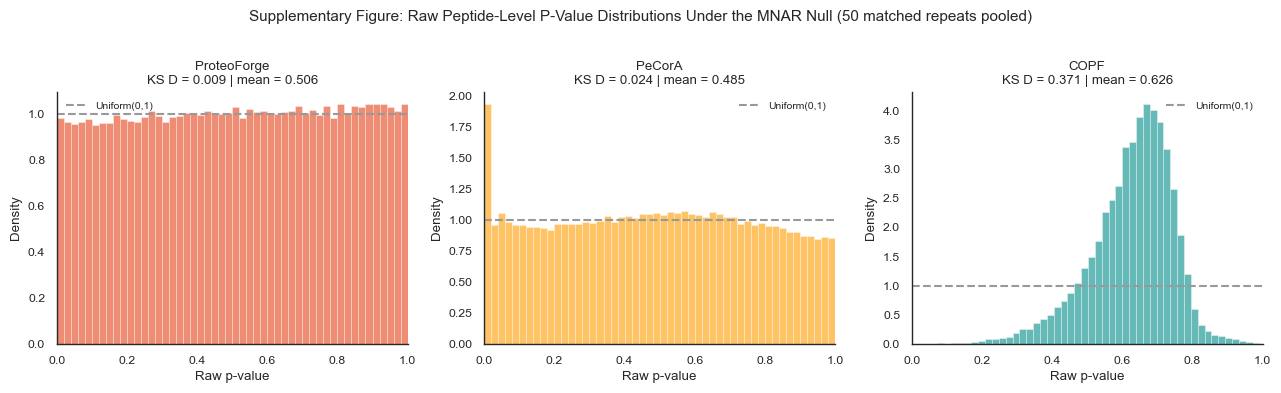

ProteoForge : KS D=0.0094, mean=0.5061, % < 0.05 = 4.86%
PeCorA      : KS D=0.0241, mean=0.4852, % < 0.05 = 6.87%
COPF        : KS D=0.3707, mean=0.6263, % < 0.05 = 0.01%


In [37]:
# ── Raw p-value distributions (all peptides incl. comp-miss) ──────
ks_D_pf,   ks_p_pf   = sp_stats.kstest(pf_raw, 'uniform')

methods_to_plot = [('ProteoForge', pf_raw, 'ProteoForge')]
ks_results = {'ProteoForge': (ks_D_pf, ks_p_pf)}

if len(pec_raw) > 0:
    ks_D_pec, ks_p_pec = sp_stats.kstest(pec_raw, 'uniform')
    methods_to_plot.append(('PeCorA', pec_raw, 'PeCorA'))
    ks_results['PeCorA'] = (ks_D_pec, ks_p_pec)
if len(copf_raw) > 0:
    ks_D_copf, ks_p_copf = sp_stats.kstest(copf_raw, 'uniform')
    methods_to_plot.append(('COPF', copf_raw, 'COPF'))
    ks_results['COPF'] = (ks_D_copf, ks_p_copf)

n_panels = len(methods_to_plot)
fig, axes = plt.subplots(1, n_panels, figsize=(4.3 * n_panels, 3.8))
if n_panels == 1:
    axes = [axes]
n_bins = 50

for ax, (name, vals, mkey) in zip(axes, methods_to_plot):
    ks_D = ks_results[mkey][0]
    ax.hist(vals, bins=n_bins, density=True, color=METHOD_COLORS[mkey],
            alpha=0.65, edgecolor='white', linewidth=0.4)
    ax.axhline(1.0, color=DIAG_COLOR, ls='--', lw=1.5, label='Uniform(0,1)')
    ax.set_xlabel('Raw p-value')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nKS D = {ks_D:.3f} | mean = {vals.mean():.3f}', fontsize=9.5)
    ax.legend(fontsize=7.5, frameon=False)
    ax.set_xlim(0, 1)
    sns.despine(ax=ax)

fig.suptitle(
    f'Supplementary Figure: Raw Peptide-Level P-Value Distributions Under the MNAR Null ({matched_repeat_label})',
    fontsize=11,
    y=1.02,
)
fig.tight_layout()
save_fig(fig, 'mnar_raw_pval_histogram')
plt.show()

for name, (ks_D, ks_p) in ks_results.items():
    vals = pf_raw if name == 'ProteoForge' else (pec_raw if name == 'PeCorA' else copf_raw)
    print(f"{name:12s}: KS D={ks_D:.4f}, mean={vals.mean():.4f}, "
          f"% < 0.05 = {(vals < 0.05).mean()*100:.2f}%")

### Q–Q Comparison

Agreement with the identity line indicates close correspondence with the Uniform(0,1) null. Systematic upward deviation would indicate anti-conservative behavior, whereas strong downward deviation would indicate conservative behavior.

  Saved: mnar_qq_uniform.png / .pdf


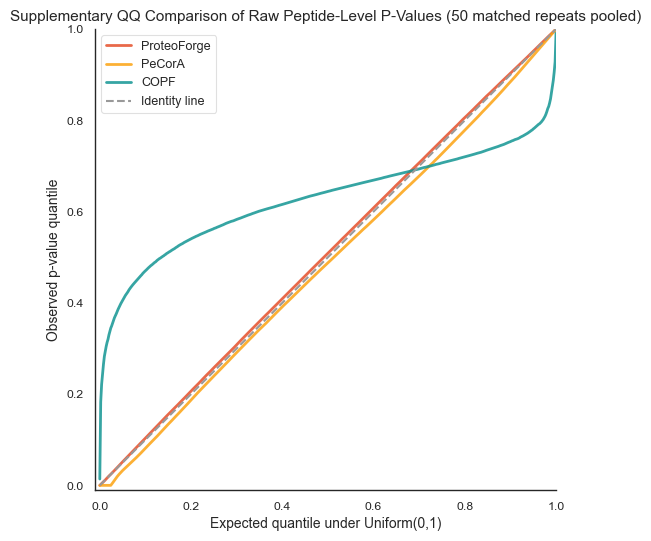

In [38]:
n_pts = 500

fig, ax = plt.subplots(figsize=(5.5, 5.5))
for name, raw_vals, mkey in methods_to_plot:
    obs = np.sort(raw_vals)
    n = len(obs)
    expected = np.linspace(1 / n, 1 - 1 / n, n)
    common_x = np.linspace(0, 1, n_pts)
    obs_interp = np.interp(common_x, expected, obs)
    ax.plot(common_x, obs_interp, color=METHOD_COLORS[mkey],
            linewidth=2.0, label=name, alpha=0.85)

ax.plot([0, 1], [0, 1], '--', color=DIAG_COLOR, linewidth=1.5, label='Identity line')
ax.set_xlim(-0.01, 1)
ax.set_ylim(-0.01, 1)
ax.set_aspect('equal')
ax.set_xlabel('Expected quantile under Uniform(0,1)', fontsize=10)
ax.set_ylabel('Observed p-value quantile', fontsize=10)
ax.set_title(f'Supplementary QQ Comparison of Raw Peptide-Level P-Values ({matched_repeat_label})', fontsize=11)
ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)
fig.tight_layout()
save_fig(fig, 'mnar_qq_uniform')
plt.show()

---

## Part 2 · Peptide-Level Calibration Under the MNAR Null

**Question:** After MNAR completion, does the peptide-level false positive rate remain aligned with the nominal threshold?

Each trajectory is computed separately within each repeat and then summarized across runs. Solid lines denote the median empirical false positive rate, while shaded ribbons show the run-wise 95% interval.

$$
\mathrm{FPR}(\alpha) = \frac{\#\{p \leq \alpha\}}{N_{\mathrm{tests}}},
$$

  Saved: mnar_peptide_fdr_calibration.png / .pdf


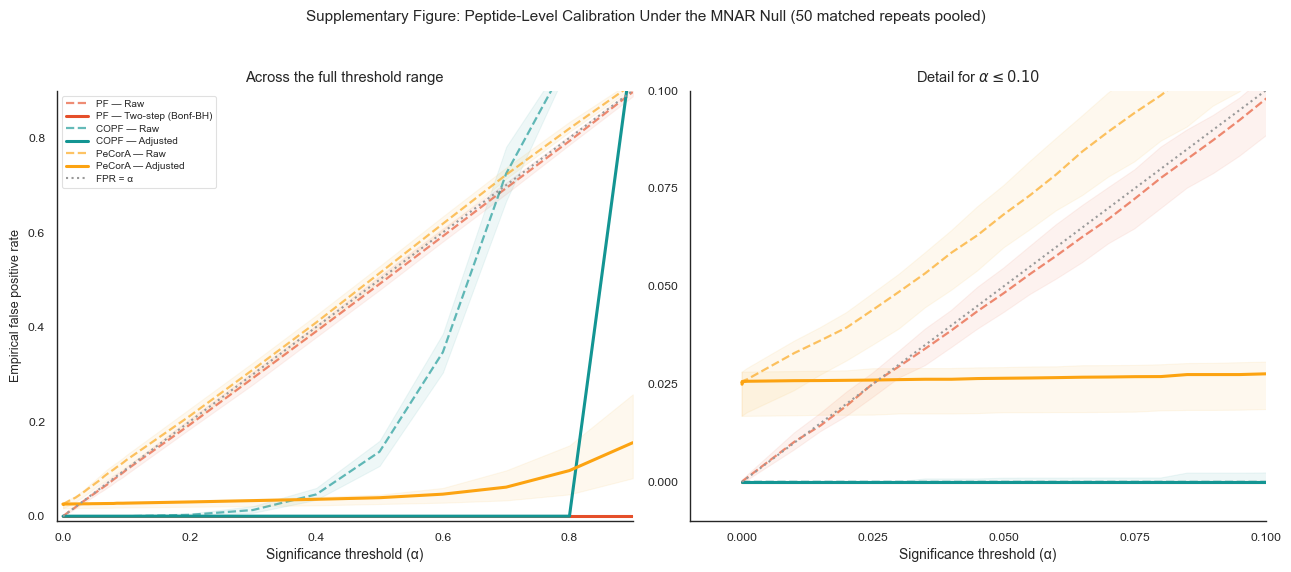


α = 0.01:
  PF Raw                        : median FPR = 0.0102
  PF Two-step (Bonf-BH)         : median FPR = 0.0000
  COPF Raw                      : median FPR = 0.0000
  COPF Adj                      : median FPR = 0.0000
  PeCorA Raw                    : median FPR = 0.0329
  PeCorA Adj                    : median FPR = 0.0258

α = 0.05:
  PF Raw                        : median FPR = 0.0482
  PF Two-step (Bonf-BH)         : median FPR = 0.0000
  COPF Raw                      : median FPR = 0.0000
  COPF Adj                      : median FPR = 0.0000
  PeCorA Raw                    : median FPR = 0.0684
  PeCorA Adj                    : median FPR = 0.0265

α = 0.10:
  PF Raw                        : median FPR = 0.0978
  PF Two-step (Bonf-BH)         : median FPR = 0.0000
  COPF Raw                      : median FPR = 0.0000
  COPF Adj                      : median FPR = 0.0000
  PeCorA Raw                    : median FPR = 0.1186
  PeCorA Adj                    : median FPR = 0.

In [39]:
plot_mask  = alpha_arr < 1.0
alpha_plot = alpha_arr[plot_mask]

# ── PF: raw & corrected calibration curves (all peptides) ─────────
pf_raw_cal = {}
cond_df = raw_pval_store[cond_name]
for rid, run_df in cond_df.groupby('run'):
    pvals = run_df['pval'].dropna().values
    n = len(pvals)
    pf_raw_cal[rid] = np.array([(pvals <= a).sum() / n for a in alpha_arr])

run_ids_raw = sorted(pf_raw_cal.keys())
raw_mat = np.vstack([pf_raw_cal[rid][plot_mask] for rid in run_ids_raw])

default_runs = sorted(all_df['run'].unique())
default_mat = np.vstack([
    cal_curves[(DEFAULT_CORRECTION, rid)][plot_mask] for rid in default_runs])

# ── COPF & PeCorA calibration curves (all peptides) ──────────────
copf_raw_cal, copf_adj_cal = {}, {}
for i, df_c in enumerate(copf_runs):
    rid = copf_run_ids[i]
    raw_pv = df_c['proteoform_score_pval'].dropna().values
    adj_pv = df_c['proteoform_score_pval_adj'].dropna().values
    copf_raw_cal[rid] = np.array([(raw_pv <= a).sum() / len(raw_pv) for a in alpha_arr])
    copf_adj_cal[rid] = np.array([(adj_pv <= a).sum() / len(adj_pv) for a in alpha_arr])

pec_raw_cal, pec_adj_cal = {}, {}
for i, df_p in enumerate(pec_runs):
    rid = pec_run_ids[i]
    raw_pv = df_p['pvalue'].dropna().values
    adj_pv = df_p['adj_pval'].dropna().values
    pec_raw_cal[rid] = np.array([(raw_pv <= a).sum() / len(raw_pv) for a in alpha_arr])
    pec_adj_cal[rid] = np.array([(adj_pv <= a).sum() / len(adj_pv) for a in alpha_arr])

# ── Build curve matrix lists ──────────────────────────────────────
curves_data = [
    ('PF — Raw', raw_mat, 'ProteoForge', '--', 1.6, 0.65, 6),
    (f'PF — {DEFAULT_CORRECTION}', default_mat, 'ProteoForge', '-', 2.2, 1.0, 8),
]
if copf_raw_cal:
    copf_raw_mat = np.vstack([copf_raw_cal[r][plot_mask] for r in sorted(copf_raw_cal)])
    copf_adj_mat = np.vstack([copf_adj_cal[r][plot_mask] for r in sorted(copf_adj_cal)])
    curves_data.append(('COPF — Raw', copf_raw_mat, 'COPF', '--', 1.6, 0.65, 6))
    curves_data.append(('COPF — Adjusted', copf_adj_mat, 'COPF', '-', 2.2, 1.0, 8))
if pec_raw_cal:
    pec_raw_mat = np.vstack([pec_raw_cal[r][plot_mask] for r in sorted(pec_raw_cal)])
    pec_adj_mat = np.vstack([pec_adj_cal[r][plot_mask] for r in sorted(pec_adj_cal)])
    curves_data.append(('PeCorA — Raw', pec_raw_mat, 'PeCorA', '--', 1.6, 0.65, 6))
    curves_data.append(('PeCorA — Adjusted', pec_adj_mat, 'PeCorA', '-', 2.2, 1.0, 8))

# ── Two-panel figure ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for panel_idx, (xlim, title_sfx) in enumerate([
    (alpha_plot.max(), 'Across the full threshold range'),
    (0.10, r'Detail for $\alpha \leq 0.10$'),
]):
    ax = axes[panel_idx]
    for label, mat, mkey, ls, lw, a, zo in curves_data:
        ax.plot(alpha_plot, np.median(mat, axis=0),
                color=METHOD_COLORS[mkey], linewidth=lw, linestyle=ls,
                label=label, zorder=zo, alpha=a)
        ax.fill_between(alpha_plot,
                        np.percentile(mat, 2.5, axis=0),
                        np.percentile(mat, 97.5, axis=0),
                        color=METHOD_COLORS[mkey], alpha=0.07, zorder=zo - 1)

    ax.plot([0, xlim], [0, xlim], ':', color=DIAG_COLOR, linewidth=1.5,
            label='FPR = α', zorder=10)
    ax.set_xlim(-0.01, xlim)
    ax.set_ylim(-0.01, xlim)
    ax.set_xlabel('Significance threshold (α)', fontsize=10)
    ax.set_title(title_sfx, fontsize=10.5, pad=6)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    sns.despine(ax=ax)
    if panel_idx == 0:
        ax.legend(fontsize=7.2, frameon=True, framealpha=0.9, edgecolor='#dddddd',
                  loc='upper left', handlelength=2.2, labelspacing=0.35, ncol=1)

axes[0].set_ylabel('Empirical false positive rate', fontsize=9)
fig.suptitle(
    f'Supplementary Figure: Peptide-Level Calibration Under the MNAR Null ({matched_repeat_label})',
    fontsize=11,
    y=1.03,
)
fig.tight_layout()
save_fig(fig, 'mnar_peptide_fdr_calibration')
plt.show()

for a_check in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(alpha_plot - a_check))
    print(f"\nα = {a_check:.2f}:")
    print(f"  {'PF Raw':30s}: median FPR = {np.median(raw_mat[:, idx]):.4f}")
    print(f"  {'PF ' + DEFAULT_CORRECTION:30s}: median FPR = {np.median(default_mat[:, idx]):.4f}")
    if copf_raw_cal:
        print(f"  {'COPF Raw':30s}: median FPR = {np.median(copf_raw_mat[:, idx]):.4f}")
        print(f"  {'COPF Adj':30s}: median FPR = {np.median(copf_adj_mat[:, idx]):.4f}")
    if pec_raw_cal:
        print(f"  {'PeCorA Raw':30s}: median FPR = {np.median(pec_raw_mat[:, idx]):.4f}")
        print(f"  {'PeCorA Adj':30s}: median FPR = {np.median(pec_adj_mat[:, idx]):.4f}")

---

## Part 3 · Protein-Level Calibration Under the MNAR Null

**Question:** Under the MNAR null, how often does each method call a null protein significant?

A protein is counted as significant when any of its peptides satisfies $p_{\mathrm{adj}} \leq \alpha$. The plotted curves summarize repeat-level protein false positive rates using the median across runs with a run-wise 95% interval.

  Saved: mnar_protein_fpr.png / .pdf


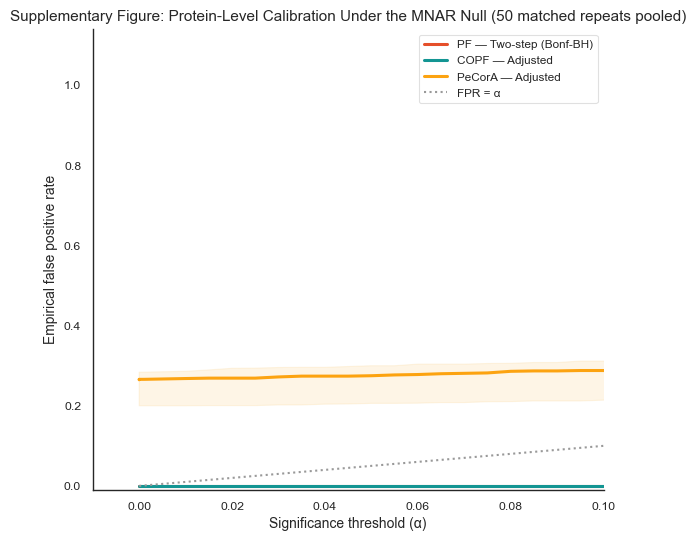

α = 0.01:
  PF:     0.0000
  COPF:   0.0000
  PeCorA: 0.2680
α = 0.05:
  PF:     0.0000
  COPF:   0.0000
  PeCorA: 0.2750


In [40]:
# ── ProteoForge protein FPR (all proteins) ────────────────────────
pf_prot_cal = {}
for rid, run_df in all_df.groupby('run'):
    adj = run_df[['Protein', 'adj_pval']].dropna()
    n_prot = adj['Protein'].nunique()
    fprs = []
    for a in alpha_arr:
        n_fp = adj.loc[adj['adj_pval'] <= a, 'Protein'].nunique()
        fprs.append(n_fp / n_prot if n_prot > 0 else 0.0)
    pf_prot_cal[rid] = np.array(fprs)

pf_prot_mat = np.vstack([pf_prot_cal[r][plot_mask] for r in sorted(pf_prot_cal)])

# ── COPF protein FPR (all proteins) ──────────────────────────────
copf_prot_cal = {}
for i, df_c in enumerate(copf_runs):
    rid = copf_run_ids[i]
    adj_pv = df_c['proteoform_score_pval_adj'].dropna()
    pids = df_c.loc[adj_pv.index, 'protein_id']
    n_prot = pids.nunique()
    fprs = []
    for a in alpha_arr:
        sig_mask = adj_pv <= a
        n_fp = pids[sig_mask].nunique()
        fprs.append(n_fp / n_prot if n_prot > 0 else 0.0)
    copf_prot_cal[rid] = np.array(fprs)

# ── PeCorA protein FPR (all proteins) ────────────────────────────
pec_prot_cal = {}
for i, df_p in enumerate(pec_runs):
    rid = pec_run_ids[i]
    adj_pv = df_p['adj_pval'].dropna()
    pids = df_p.loc[adj_pv.index, 'Protein']
    n_prot = pids.nunique()
    fprs = []
    for a in alpha_arr:
        sig_mask = adj_pv <= a
        n_fp = pids[sig_mask].nunique()
        fprs.append(n_fp / n_prot if n_prot > 0 else 0.0)
    pec_prot_cal[rid] = np.array(fprs)

# ── Compute dynamic y-limit ──────────────────────────────────────
all_meds = []
for cal_dict in [pf_prot_cal, copf_prot_cal, pec_prot_cal]:
    if cal_dict:
        mat = np.vstack([cal_dict[r][plot_mask] for r in sorted(cal_dict)])
        all_meds.append(np.median(mat, axis=0).max())
y_max = max(0.10, max(all_meds) * 1.15)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5.5))

for label, cal_dict, mkey, ls, lw in [
    (f'PF — {DEFAULT_CORRECTION}', pf_prot_cal,   'ProteoForge', '-',  2.2),
    ('COPF — Adjusted',            copf_prot_cal, 'COPF',        '-',  2.2),
    ('PeCorA — Adjusted',          pec_prot_cal,  'PeCorA',      '-',  2.2),
]:
    if not cal_dict:
        continue
    mat = np.vstack([cal_dict[r][plot_mask] for r in sorted(cal_dict)])
    ax.plot(alpha_plot, np.median(mat, axis=0),
            color=METHOD_COLORS[mkey], linewidth=lw, linestyle=ls, label=label)
    ax.fill_between(alpha_plot,
                    np.percentile(mat, 2.5, axis=0),
                    np.percentile(mat, 97.5, axis=0),
                    color=METHOD_COLORS[mkey], alpha=0.10)

ax.plot([0, 0.10], [0, 0.10], ':', color=DIAG_COLOR, linewidth=1.5,
        label='FPR = α')
ax.set_xlim(-0.01, 0.10)
ax.set_ylim(-0.01, y_max)
ax.set_xlabel('Significance threshold (α)', fontsize=10)
ax.set_ylabel('Empirical false positive rate', fontsize=10)
ax.set_title(f'Supplementary Figure: Protein-Level Calibration Under the MNAR Null ({matched_repeat_label})', fontsize=11)
ax.legend(fontsize=8.5, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)
fig.tight_layout()
save_fig(fig, 'mnar_protein_fpr')
plt.show()

for a_check in [0.01, 0.05]:
    idx = np.argmin(np.abs(alpha_plot - a_check))
    print(f"α = {a_check:.2f}:")
    print(f"  PF:     {np.median(pf_prot_mat[:, idx]):.4f}")
    if copf_prot_cal:
        copf_prot_mat = np.vstack([copf_prot_cal[r][plot_mask] for r in sorted(copf_prot_cal)])
        print(f"  COPF:   {np.median(copf_prot_mat[:, idx]):.4f}")
    if pec_prot_cal:
        pec_prot_mat = np.vstack([pec_prot_cal[r][plot_mask] for r in sorted(pec_prot_cal)])
        print(f"  PeCorA: {np.median(pec_prot_mat[:, idx]):.4f}")

---

## Part 4 · Grouping FPR (MNAR Null)

**Question:** Under the MNAR null, how often are proteoform groups predicted when none exist?

A false proteoform detection requires both a significant peptide and assignment to a non-singleton cluster. As above, repeat-level grouping false positive rates are summarized by the across-run median with a run-wise 95% interval.

  Saved: mnar_grouping_fpr.png / .pdf


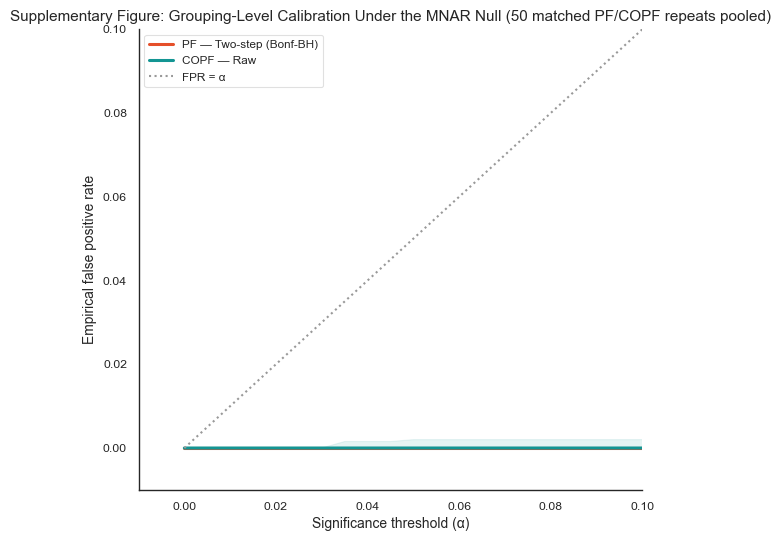

α = 0.01: PF grouping FPR = 0.0000
          COPF grouping FPR = 0.0000
α = 0.05: PF grouping FPR = 0.0000
          COPF grouping FPR = 0.0000


In [41]:
# ── ProteoForge grouping FPR (all peptides) ───────────────────────
pf_grp_cal = {}
for rid, run_df in all_df.groupby('run'):
    prot_pep = (run_df[['Protein', 'PeptideID', 'adj_pval', 'ClusterID']]
                .drop_duplicates(subset=['Protein', 'PeptideID'])
                .dropna(subset=['adj_pval']))
    n_prot = prot_pep['Protein'].nunique()
    fprs = []
    for a in alpha_arr:
        sig = prot_pep[prot_pep['adj_pval'] <= a]
        if len(sig) == 0:
            fprs.append(0.0)
            continue
        grp = sig.groupby('Protein').agg(n_clusters=('ClusterID', 'nunique'))
        n_fp = (grp['n_clusters'] > 1).sum()
        fprs.append(n_fp / n_prot if n_prot > 0 else 0.0)
    pf_grp_cal[rid] = np.array(fprs)

pf_grp_mat = np.vstack([pf_grp_cal[r][plot_mask] for r in sorted(pf_grp_cal)])

# ── COPF grouping FPR (all proteins) ─────────────────────────────
copf_grp_cal = {}
for i, df_c in enumerate(copf_runs):
    rid = copf_run_ids[i]
    n_prot = df_c['protein_id'].nunique()
    fprs = []
    for a in alpha_arr:
        grp = df_c.groupby('protein_id').agg(
            n_cluster=('cluster', 'nunique'),
            any_sig=('proteoform_score_pval', lambda x: (x < a).any()),
        )
        n_fp = ((grp['n_cluster'] > 1) & grp['any_sig']).sum()
        fprs.append(n_fp / n_prot if n_prot > 0 else 0.0)
    copf_grp_cal[rid] = np.array(fprs)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5.5))

for label, cal_dict, mkey, ls, lw in [
    (f'PF — {DEFAULT_CORRECTION}', pf_grp_cal,   'ProteoForge', '-',  2.2),
    ('COPF — Raw',                 copf_grp_cal, 'COPF',        '-',  2.2),
]:
    if not cal_dict:
        continue
    mat = np.vstack([cal_dict[r][plot_mask] for r in sorted(cal_dict)])
    ax.plot(alpha_plot, np.median(mat, axis=0),
            color=METHOD_COLORS[mkey], linewidth=lw, linestyle=ls, label=label)
    ax.fill_between(alpha_plot,
                    np.percentile(mat, 2.5, axis=0),
                    np.percentile(mat, 97.5, axis=0),
                    color=METHOD_COLORS[mkey], alpha=0.10)

ax.plot([0, 0.10], [0, 0.10], ':', color=DIAG_COLOR, linewidth=1.5,
        label='FPR = α')
ax.set_xlim(-0.01, 0.10)
ax.set_ylim(-0.01, max(0.10, np.max(pf_grp_mat) * 1.1))
ax.set_xlabel('Significance threshold (α)', fontsize=10)
ax.set_ylabel('Empirical false positive rate', fontsize=10)
ax.set_title(f'Supplementary Figure: Grouping-Level Calibration Under the MNAR Null ({grouping_repeat_label})', fontsize=11)
ax.legend(fontsize=8.5, frameon=True, framealpha=0.9, edgecolor='#dddddd')
sns.despine(ax=ax)
fig.tight_layout()
save_fig(fig, 'mnar_grouping_fpr')
plt.show()

for a_check in [0.01, 0.05]:
    idx = np.argmin(np.abs(alpha_plot - a_check))
    print(f"α = {a_check:.2f}: PF grouping FPR = {np.median(pf_grp_mat[:, idx]):.4f}")
    if copf_grp_cal:
        copf_grp_mat_t = np.vstack([copf_grp_cal[r][plot_mask] for r in sorted(copf_grp_cal)])
        print(f"          COPF grouping FPR = {np.median(copf_grp_mat_t[:, idx]):.4f}")

## Part 5. Comparison to the No-MNAR Baseline

This comparison benchmarks the MNAR-null calibration against the matched no-missingness baseline from the main calibration notebook. The overlay isolates the incremental effect of structured MNAR missingness on ProteoForge's peptide-level false positive rate.

The panel is drawn only when the matched no-missingness ProteoForge cache exists at the same repeat count. If that cache has not yet been created by the companion no-missingness notebook, this section should be interpreted as pending rather than absent evidence.

In [42]:
# ── Load no-MNAR baseline ProteoForge results ─────────────────────
nomnar_cache = os.path.join(nomnar_output_path,
    f'rawpvals_full_Raw_no_missingness_K{K}.feather')

has_baseline = os.path.exists(nomnar_cache)
if has_baseline:
    nomnar_df = pd.read_feather(nomnar_cache)
    nomnar_run_count = nomnar_df['run'].nunique()
    print(f"Loaded no-MNAR baseline: {len(nomnar_df):,} p-values, "
          f"{nomnar_run_count} runs")

    if nomnar_run_count == pf_run_count:
        comparison_repeat_label = f'{pf_run_count} matched repeats pooled'
    else:
        comparison_repeat_label = f'MNAR={pf_run_count}, no-MNAR={nomnar_run_count} repeats'

    # Raw calibration curves for no-MNAR
    nomnar_raw_cal = {}
    for rid, run_df in nomnar_df.groupby('run'):
        pvals = run_df['pval'].dropna().values
        n = len(pvals)
        nomnar_raw_cal[rid] = np.array([(pvals <= a).sum() / n for a in alpha_arr])
    nomnar_raw_mat = np.vstack([nomnar_raw_cal[r][plot_mask] for r in sorted(nomnar_raw_cal)])
else:
    print("No-MNAR baseline not found — run FDRCalibration notebook first.")
    nomnar_raw_mat = None
    comparison_repeat_label = f'MNAR={pf_run_count} repeats; no matched baseline cache'

# ── Comparison plot (MNAR vs no-MNAR) ────────────────────────────
if nomnar_raw_mat is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    comparison_curves = [
        ('No MNAR — PF Raw', nomnar_raw_mat, '#888888', '--', 2.0, 0.7, 5),
        ('MNAR — PF Raw', raw_mat, '#e54f2a', '-', 2.2, 1.0, 8),
    ]

    for panel_idx, (xlim, title_sfx) in enumerate([
        (alpha_plot.max(), 'Across the full threshold range'),
        (0.10, r'Detail for $\alpha \leq 0.10$'),
    ]):
        ax = axes[panel_idx]
        for label, mat, color, ls, lw, a, zo in comparison_curves:
            ax.plot(alpha_plot, np.median(mat, axis=0),
                    color=color, linewidth=lw, linestyle=ls,
                    label=label, zorder=zo, alpha=a)
            ax.fill_between(alpha_plot,
                            np.percentile(mat, 2.5, axis=0),
                            np.percentile(mat, 97.5, axis=0),
                            color=color, alpha=0.07, zorder=zo - 1)

        ax.plot([0, xlim], [0, xlim], ':', color=DIAG_COLOR, linewidth=1.5,
                label='FPR = α', zorder=10)
        ax.set_xlim(-0.01, xlim)
        ax.set_ylim(-0.01, xlim)
        ax.set_xlabel('Significance threshold (α)', fontsize=10)
        ax.set_title(title_sfx, fontsize=10.5, pad=6)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        sns.despine(ax=ax)
        if panel_idx == 0:
            ax.legend(fontsize=8.5, frameon=True, framealpha=0.9, edgecolor='#dddddd',
                      loc='upper left')

    axes[0].set_ylabel('Empirical false positive rate', fontsize=9)
    fig.suptitle(
        f'Supplementary Comparison: ProteoForge Calibration With and Without MNAR Missingness ({comparison_repeat_label})',
        fontsize=11,
        y=1.03,
    )
    fig.tight_layout()
    save_fig(fig, 'mnar_vs_nomnar_comparison')
    plt.show()

    for a_check in [0.01, 0.05, 0.10]:
        idx = np.argmin(np.abs(alpha_plot - a_check))
        mnar_med = np.median(raw_mat[:, idx])
        nomnar_med = np.median(nomnar_raw_mat[:, idx])
        print(f"α = {a_check:.2f}: MNAR FPR = {mnar_med:.4f}, "
              f"No-MNAR FPR = {nomnar_med:.4f}, "
              f"Δ = {mnar_med - nomnar_med:+.4f}")

No-MNAR baseline not found — run FDRCalibration notebook first.


## Summary Table

The table below reports median empirical false positive rates at representative significance thresholds for the peptide-level analyses shown above. In the refreshed publication run, these summaries are based on **50 matched repeats pooled** across ProteoForge, PeCorA, and COPF for the MNAR-specific analyses.

In [43]:
# ── Summary table at key α thresholds ─────────────────────────────
summary_rows = []
for a_check in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(alpha_plot - a_check))
    row = {'α': a_check}

    # ProteoForge
    row['PF Raw FPR'] = f"{np.median(raw_mat[:, idx]):.4f}"
    row[f'PF {DEFAULT_CORRECTION} FPR'] = f"{np.median(default_mat[:, idx]):.4f}"

    # COPF
    if copf_raw_cal:
        copf_rm = np.vstack([copf_raw_cal[r][plot_mask] for r in sorted(copf_raw_cal)])
        copf_am = np.vstack([copf_adj_cal[r][plot_mask] for r in sorted(copf_adj_cal)])
        row['COPF Raw FPR'] = f"{np.median(copf_rm[:, idx]):.4f}"
        row['COPF Adj FPR'] = f"{np.median(copf_am[:, idx]):.4f}"

    # PeCorA
    if pec_raw_cal:
        pec_rm = np.vstack([pec_raw_cal[r][plot_mask] for r in sorted(pec_raw_cal)])
        pec_am = np.vstack([pec_adj_cal[r][plot_mask] for r in sorted(pec_adj_cal)])
        row['PeCorA Raw FPR'] = f"{np.median(pec_rm[:, idx]):.4f}"
        row['PeCorA Adj FPR'] = f"{np.median(pec_am[:, idx]):.4f}"

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(
    summary_df.style
    .set_caption(f'Supplementary Table: Median Peptide-Level False Positive Rates Under the MNAR Null ({matched_repeat_label})')
    .hide(axis='index')
)

# Save
tables_dir = os.path.join(output_path, 'tables')
os.makedirs(tables_dir, exist_ok=True)
summary_df.to_csv(os.path.join(tables_dir, f'mnar_null_fpr_summary_K{K}.csv'), index=False)
print(f"\nSaved: tables/mnar_null_fpr_summary_K{K}.csv")
print(f"Run coverage captured in this table: {matched_repeat_label}")

α,PF Raw FPR,PF Two-step (Bonf-BH) FPR,COPF Raw FPR,COPF Adj FPR,PeCorA Raw FPR,PeCorA Adj FPR
0.010000,0.0102,0.0000,0.0000,0.0000,0.0329,0.0258
0.050000,0.0482,0.0000,0.0000,0.0000,0.0684,0.0265
0.100000,0.0978,0.0000,0.0000,0.0000,0.1186,0.0276



Saved: tables/mnar_null_fpr_summary_K50.csv
Run coverage captured in this table: 50 matched repeats pooled


## Part 6. Non-Null Sim2 Operating Points

Parts 1–5 establish that the MNAR null remains well controlled. To complement that result with a non-null view, this section reuses the maintained `classification_stats` summaries and shows **two representative Sim2 datasets** at the matched operating point used by the revision pipeline.

The selected scenarios span a mild-to-severe MNAR range:

- `P20_Q20`: 20% protein-level missingness and 20% peptide-level missingness
- `P80_Q60`: 80% protein-level missingness and 60% peptide-level missingness

For each scenario, empirical FDR is computed as `1 - precision` at the matched operating point, and power is the corresponding sensitivity. This is therefore the closest maintained analogue to the non-null FDR-vs-power panels in the main calibration notebook.

In [47]:
classification_stats_dir = os.path.join(
    PROJECT_ROOT, 'Revisions', 'outputs', 'simulation', 'classification_stats'
)
id_operating_path = os.path.join(classification_stats_dir, 'identification_operating_point_table.csv')
grp_operating_path = os.path.join(classification_stats_dir, 'grouping_operating_point_table.csv')

sim2_scenarios = {
    'P20_Q20': 'Sim2-A: P20% | pep 20%',
    'P80_Q60': 'Sim2-B: P80% | pep 60%',
}

id_operating = pd.read_csv(id_operating_path)
grp_operating = pd.read_csv(grp_operating_path)

id_sim2 = (
    id_operating.loc[
        (id_operating['simulation'] == 'Sim2')
        & (id_operating['scenario_key'].isin(sim2_scenarios))
        & (id_operating['matched_fpr_target'] == 0.05)
    ]
    .copy()
)
grp_sim2 = (
    grp_operating.loc[
        (grp_operating['simulation'] == 'Sim2')
        & (grp_operating['scenario_key'].isin(sim2_scenarios))
        & (grp_operating['matched_fpr_target'] == 0.05)
    ]
    .copy()
)

if id_sim2.empty or grp_sim2.empty:
    raise FileNotFoundError('Sim2 operating-point summaries were not found in classification_stats.')

for df_level, level_name in [(id_sim2, 'Identification'), (grp_sim2, 'Grouping')]:
    df_level['Level'] = level_name
    df_level['Scenario'] = df_level['scenario_key'].map(sim2_scenarios)
    df_level['Empirical FDR'] = 1.0 - df_level['matched_precision']
    df_level['Power'] = df_level['matched_sensitivity']

print(f"Loaded identification operating points: {len(id_sim2)} rows")
print(f"Loaded grouping operating points: {len(grp_sim2)} rows")
print('Scenarios:', ', '.join(sim2_scenarios.values()))

Loaded identification operating points: 6 rows
Loaded grouping operating points: 4 rows
Scenarios: Sim2-A: P20% | pep 20%, Sim2-B: P80% | pep 60%


  Saved: sim2_nonnull_operating_points.png / .pdf


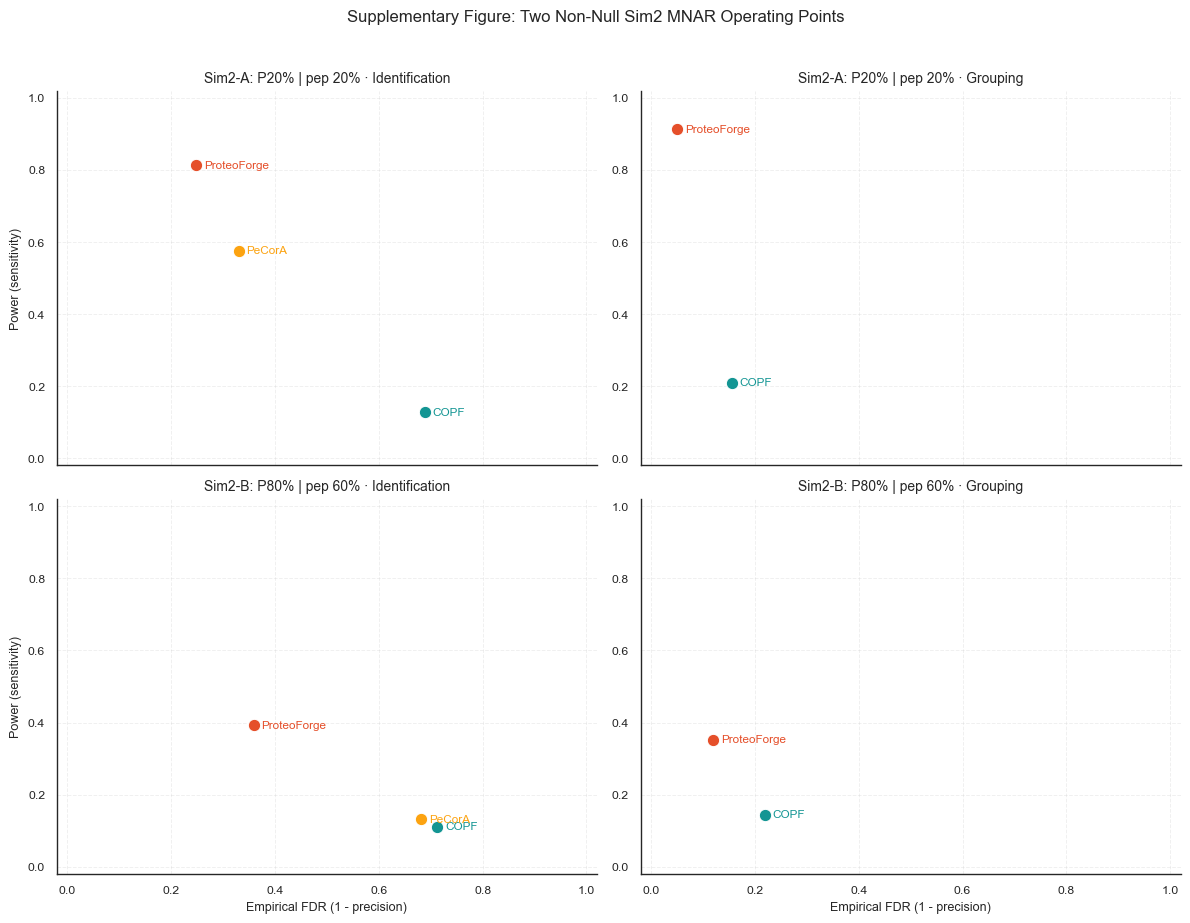

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex='col', sharey='col')

plot_specs = [
    ('Sim2-A: P20% | pep 20%', id_sim2, grp_sim2),
    ('Sim2-B: P80% | pep 60%', id_sim2, grp_sim2),
]
level_titles = ['Identification', 'Grouping']
level_methods = {
    'Identification': ['ProteoForge', 'PeCorA', 'COPF'],
    'Grouping': ['ProteoForge', 'COPF'],
}

for row_idx, (scenario_label, id_df_plot, grp_df_plot) in enumerate(plot_specs):
    for col_idx, (level_name, df_plot) in enumerate([
        ('Identification', id_df_plot),
        ('Grouping', grp_df_plot),
    ]):
        ax = axes[row_idx, col_idx]
        subset = (
            df_plot.loc[df_plot['Scenario'] == scenario_label]
            .copy()
            .sort_values('method')
        )
        subset = subset.loc[subset['method'].isin(level_methods[level_name])].copy()

        for _, row in subset.iterrows():
            ax.scatter(
                row['Empirical FDR'],
                row['Power'],
                s=80,
                color=METHOD_COLORS[row['method']],
                edgecolor='white',
                linewidth=0.8,
                zorder=3,
            )
            ax.text(
                row['Empirical FDR'] + 0.015,
                row['Power'],
                row['method'],
                fontsize=8.5,
                va='center',
                color=METHOD_COLORS[row['method']],
            )

        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(axis='both', linestyle='--', linewidth=0.7, alpha=0.3)
        sns.despine(ax=ax)
        ax.set_title(f'{scenario_label} · {level_titles[col_idx]}', fontsize=10)
        if row_idx == 1:
            ax.set_xlabel('Empirical FDR (1 - precision)', fontsize=9)
        if col_idx == 0:
            ax.set_ylabel('Power (sensitivity)', fontsize=9)

fig.suptitle('Supplementary Figure: Two Non-Null Sim2 MNAR Operating Points', fontsize=12, y=1.02)
fig.tight_layout()
save_fig(fig, 'sim2_nonnull_operating_points')
plt.show()

In [49]:
sim2_summary = pd.concat([
    id_sim2[['Scenario', 'Level', 'method', 'matched_actual_fpr', 'Empirical FDR', 'Power', 'matched_precision']].copy(),
    grp_sim2[['Scenario', 'Level', 'method', 'matched_actual_fpr', 'Empirical FDR', 'Power', 'matched_precision']].copy(),
], ignore_index=True)

sim2_summary = sim2_summary.rename(columns={
    'method': 'Method',
    'matched_actual_fpr': 'Matched Null-FPR',
    'matched_precision': 'Precision',
})
sim2_summary = sim2_summary.sort_values(['Scenario', 'Level', 'Method']).reset_index(drop=True)

display(
    sim2_summary.style
    .set_caption('Supplementary Table: Two Non-Null Sim2 MNAR Operating Points')
    .hide(axis='index')
    .format({
        'Matched Null-FPR': '{:.3f}',
        'Empirical FDR': '{:.3f}',
        'Power': '{:.3f}',
        'Precision': '{:.3f}',
    })
)

sim2_tbl_path = os.path.join(output_path, 'tables', 'sim2_nonnull_operating_points.csv')
os.makedirs(os.path.dirname(sim2_tbl_path), exist_ok=True)
sim2_summary.to_csv(sim2_tbl_path, index=False)
print(f"Saved: {project_relative_label(sim2_tbl_path)}")

Scenario,Level,Method,Matched Null-FPR,Empirical FDR,Power,Precision
Sim2-A: P20% | pep 20%,Grouping,COPF,0.036,0.155,0.210,0.845
Sim2-A: P20% | pep 20%,Grouping,ProteoForge,0.048,0.050,0.913,0.950
Sim2-A: P20% | pep 20%,Identification,COPF,0.047,0.688,0.128,0.312
Sim2-A: P20% | pep 20%,Identification,PeCorA,0.050,0.330,0.576,0.670
Sim2-A: P20% | pep 20%,Identification,ProteoForge,0.050,0.248,0.812,0.752
Sim2-B: P80% | pep 60%,Grouping,COPF,0.028,0.219,0.144,0.781
Sim2-B: P80% | pep 60%,Grouping,ProteoForge,0.048,0.120,0.353,0.880
Sim2-B: P80% | pep 60%,Identification,COPF,0.050,0.713,0.111,0.287
Sim2-B: P80% | pep 60%,Identification,PeCorA,0.050,0.681,0.132,0.319
Sim2-B: P80% | pep 60%,Identification,ProteoForge,0.050,0.359,0.392,0.641


Saved: Analysis_with_ProteoForge/Revisions/outputs/simulation/mnar_fdr_calibration/tables/sim2_nonnull_operating_points.csv


**Sim2 Non-Null Takeaway:** At the milder `P20_Q20` setting, ProteoForge keeps the strongest identification operating point among the three methods and the strongest grouping operating point versus COPF, combining materially higher power with lower empirical FDR. Under the harsher `P80_Q60` setting, all methods lose power, but ProteoForge still retains the most favorable FDR-power trade-off: peptide-level power drops to roughly 39% with empirical FDR around 36%, while COPF and PeCorA are both substantially less efficient at the same matched null-FPR target.

These two Sim2 snapshots do not replace the null-calibration story above; they show that once true signal is present, the MNAR-imputed setting still preserves the main qualitative ranking seen in the non-null calibration notebook, while making the severe-missingness penalty explicit.

## Interpretation Summary

Across the refreshed **50-repeat** MNAR-null run, ProteoForge remains well calibrated at the peptide level: its raw p-values stay close to the Uniform(0,1) null (`KS D = 0.0094`), and the observed raw peptide-level false positive rate is `0.0482` at `α = 0.05`. After the default two-step correction, ProteoForge remains fully controlled in the peptide, protein, and grouping summaries over the plotted range.

PeCorA remains mildly anti-conservative at the peptide level under the MNAR-null stress test, with median raw peptide-level FPR `0.0684` at `α = 0.05`, while its adjusted peptide-level FPR remains lower (`0.0265`). The complete-condition-missing diagnostic also shows that this method reacts strongly to the structured completed subset, with nearly all complete-miss peptides called significant at raw `p < 0.05`; correspondingly, its adjusted protein-level FPR remains elevated at roughly `0.275` by `α = 0.05`.

COPF remains strongly conservative in this setting: its raw peptide-level FPR is essentially zero across the displayed thresholds, and the protein-level and grouping-level false positive rates remain at zero over the plotted range. The matched no-missingness comparison in Part 5 is still conditional on the companion K=50 ProteoForge baseline cache from the no-missingness calibration notebook.

The added non-null Sim2 snapshots show the complementary performance story once true signal is present under MNAR. At the milder `P20_Q20` operating point, ProteoForge has the best peptide-level and grouping-level FDR-power balance. At the harsher `P80_Q60` operating point, all methods degrade, but ProteoForge still retains the strongest trade-off, while the severe missingness penalty becomes visible as a substantial drop in peptide and grouping power.

In [44]:
elapsed = time.time() - startTime
minutes = int(elapsed // 60)
seconds = elapsed % 60
print(f"Notebook completed in {minutes}m {seconds:.1f}s")

Notebook completed in 8m 25.5s
